# 10. HICP Energy aggregate forecast

This notebook is the aggregation layer above the seven ECB-style energy BVAR equations.

It does **not** re-estimate the BVARs. It:

1. validates the historical HICP aggregation identities;
2. reloads the saved posterior predictive paths from notebooks 03–09;
3. applies the WOB VAT/IDT tax re-attribution to weekly petrol, diesel and liquid-fuel paths;
4. conditions the weekly fuel predictive draws on **both pre-tax and after-tax price admissibility** before HICP rebasing;
5. converts the retained weekly consumer-price paths to monthly frequency and rebases their price relatives to HICP;
6. builds the energy-relevant **car-fuels** sub-aggregate;
7. aggregates the six model components into **HICP Energy** with annual Laspeyres-type weights and December chain links;
8. computes draw-wise YoY inflation and exactly additive contributions;
9. optionally applies tax scenarios ex post;
10. saves one aggregate result store for the dashboard / orchestration layer.

### Vintage convention

`VINTAGE=None` is the normal setting. The notebook automatically selects the **latest common vintage** for which both the processed HICP aggregation inputs and all seven required forecast stores exist.

Set an explicit value such as `VINTAGE="20260808"` only when you deliberately want to pin a reproducible historical vintage.

### Predictive-price admissibility

The weekly BVARs are estimated in **absolute price changes**. Gaussian predictive innovations have unbounded support, so rare long-horizon draws can imply a non-positive price. The economically primitive BVAR price is the **pre-tax** price, so production filtering requires:

\[
P^{pre-tax,(d)}_t>0
\]

and, after tax re-attribution, also:

\[
P^{after-tax,(d)}_t>0.
\]

A violating trajectory is rejected **as a whole**; individual observations are never clipped. Baseline and tax-scenario paths use the same mask. The resulting fan is therefore a posterior predictive distribution **conditional on economically admissible positive price paths**. Rejection rates are reported explicitly; no arbitrary rejection-rate hard threshold is imposed.

### Cross-model draw pairing

The seven BVARs are estimated independently. Equal Gibbs draw numbers across models do not form a joint posterior draw. Component paths are randomly paired under the maintained cross-model independence approximation.

To avoid asymmetric bootstrap noise after admissibility filtering, the aggregate uses

\[
N_{\mathrm{agg}}=\min\{\text{requested cap},\ \text{all retained component pool sizes}\}.
\]

Thus every component is sampled **without replacement** in the production aggregate.

### Weekly tax data

Production mode uses the separate WOB `NTAX`, `IDT`, `VAT` and `WTAX` series:

\[
P^{pre-tax}\rightarrow (VAT,IDT)\rightarrow P^{after-tax}\rightarrow HICP.
\]

`WEEKLY_TAX_MODE="strict"` is the production setting.


In [2]:
1+1

2

In [3]:

from __future__ import annotations

from pathlib import Path
import hashlib
import json
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "data" / "processed").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())

MODEL_DIR_CANDIDATES = [
    PROJECT_ROOT / "src" / "model",
    PROJECT_ROOT,
    Path.cwd(),
]

REQUIRED_MODULES = (
    "energy_bvar_aggregate.py",
    "energy_bvar_io.py",
    "energy_bvar_gas.py",
    "energy_bvar_electricity.py",
    "energy_bvar_weekly_fuels.py",
    "energy_bvar_source_context.py",
)

MODEL_DIR = None
for candidate in MODEL_DIR_CANDIDATES:
    if all((candidate / name).is_file() for name in REQUIRED_MODULES):
        sys.path.insert(0, str(candidate))
        MODEL_DIR = candidate
        break

if MODEL_DIR is None:
    raise FileNotFoundError(
        "Place the canonical model files beside this notebook or in src/model/: "
        + ", ".join(REQUIRED_MODULES)
    )

from energy_bvar_io import load_energy_bvar_forecast
from energy_bvar_aggregate import (
    aggregate_component_draw_paths_laspeyres,
    aggregate_draw_paths_laspeyres,
    assert_reconstruction_suite,
    price_proxy_diagnostic_table,
    carry_last_index_path,
    draw_yoy_and_contributions,
    price_proxy_diagnostics,
    historical_model_component_reconstruction,
    historical_reconstruction_suite,
    independent_draw_pairing,
    filter_positive_price_draws,
    load_aggregation_inputs,
    rebase_price_paths_to_hicp_index,
    summarise_draw_paths,
    weekly_paths_with_history_to_monthly_mean,
)
from energy_bvar_gas import (
    expand_semester_series as expand_gas_semester_series,
    load_gas_tax_context,
    reattribute_gas_taxes,
    validate_tax_round_trip,
)
from energy_bvar_electricity import (
    expand_semester_series as expand_electricity_semester_series,
    load_electricity_tax_context,
    reattribute_electricity_taxes,
    validate_electricity_tax_round_trip,
)
from energy_bvar_weekly_fuels import (
    load_weekly_tax_context,
    reattribute_weekly_taxes,
)
from energy_bvar_source_context import load_manifest_source_frame

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 190)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Model modules: {MODEL_DIR}")


Project root: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy
Model modules: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\src\model



## 1. Configuration and forecast-store preflight

`FORECAST_NAME="unconditional"` is the baseline Notebook 10 contract.

The component notebooks must save their predictive paths once with the updated `energy_bvar_io.py`. The required two calls are:

```python
saved_result_paths = save_energy_bvar_result(result, RESULTS_ROOT)
save_energy_bvar_forecast(
    forecast_unconditional,
    saved_result_paths["directory"],
    "unconditional",
)
```

Do this in notebooks 03–09 after the forecast object has been created. It does **not** alter the model; it only persists the already-created posterior predictive paths.


In [4]:

VINTAGE = None  # None -> latest COMMON processed/forecast vintage; string -> pin exact vintage
FORECAST_NAME = "unconditional"
RESULTS_ROOT = PROJECT_ROOT / "results"

N_AGG_DRAWS = 500  # requested upper cap; effective N is min retained pool size
PAIRING_SEED = 2026

# "strict" : paper-faithful production mode; separate WOB VAT/IDT are mandatory.
# "pre_tax_proxy_fallback" : exploratory only. Uses pre-tax WOB price relatives
#                            and is rejected unless its proxy diagnostics pass.
WEEKLY_TAX_MODE = "strict"
ALLOW_WEAK_PRETAX_PROXY_FALLBACK = False

SAVE_AGGREGATE_RESULT = True

# Optional ex-post tax scenarios. None means the paper baseline:
# latest published tax state carried forward.
#
# Example for gas/electricity:
# {
#     "start_date": "2026-10-01",
#     "vat_percent": 21.0,
# }
#
# An excise scenario must also specify the exact unit expected by the adapter.
TAX_SCENARIOS = {
    "petrol": None,
    "diesel": None,
    "liquid_fuels": None,
    "gas": None,
    "electricity": None,
}

MODEL_IDS = {
    "gas": "gas",
    "electricity": "electricity",
    "heat_energy": "heat_energy",
    "solid_fuels": "solid_fuels",
    "petrol": "car_fuels_petrol",
    "diesel": "car_fuels_diesel",
    "liquid_fuels": "liquid_fuels",
}

DATASET_FILES = {
    "gas": "gas_monthly.csv",
    "electricity": "electricity_monthly.csv",
    "heat_energy": "heat_energy_monthly.csv",
    "solid_fuels": "solid_fuels_monthly.csv",
    "petrol": "car_fuels_weekly.csv",
    "diesel": "car_fuels_weekly.csv",
    "liquid_fuels": "liquid_fuels_weekly.csv",
}

PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed"


def latest_forecast_store(
    model_id: str,
    vintage: str,
    forecast_name: str,
) -> Path | None:
    """Newest complete forecast store for one model and one vintage."""
    base = RESULTS_ROOT / model_id / str(vintage)
    if not base.is_dir():
        return None
    stores = [
        run / "forecasts" / forecast_name
        for run in base.iterdir()
        if run.is_dir()
        and (run / "forecasts" / forecast_name / "forecast_metadata.json").is_file()
        and (run / "forecasts" / forecast_name / "forecast_draws.npz").is_file()
    ]
    if not stores:
        return None
    return max(stores, key=lambda path: path.stat().st_mtime_ns)


def processed_vintage_ready(path: Path) -> bool:
    """Require HICP sidecars plus all six processed model CSVs."""
    required = {
        "manifest.json",
        "hicp_indices_monthly.csv",
        "hicp_weights_annual.csv",
        *DATASET_FILES.values(),
    }
    return path.is_dir() and all((path / name).is_file() for name in required)


def forecast_stores_for_vintage(vintage: str) -> dict[str, Path | None]:
    return {
        name: latest_forecast_store(model_id, vintage, FORECAST_NAME)
        for name, model_id in MODEL_IDS.items()
    }


AUTO_SELECTED_VINTAGE = VINTAGE is None

if VINTAGE is None:
    processed_candidates = sorted(
        (
            path
            for path in PROCESSED_ROOT.iterdir()
            if processed_vintage_ready(path)
        ),
        key=lambda path: path.name,
    )

    if not processed_candidates:
        raise FileNotFoundError(
            "No processed vintage containing the model CSVs and HICP aggregation "
            f"sidecars was found below {PROCESSED_ROOT}."
        )

    common_candidates = []
    candidate_diagnostics = []

    for processed_dir in processed_candidates:
        vintage = processed_dir.name
        stores = forecast_stores_for_vintage(vintage)
        missing = [name for name, store in stores.items() if store is None]

        candidate_diagnostics.append({
            "vintage": vintage,
            "missing_forecast_stores": ", ".join(missing),
            "ready": not missing,
        })

        if not missing:
            common_candidates.append((processed_dir, stores))

    if not common_candidates:
        display(pd.DataFrame(candidate_diagnostics).set_index("vintage"))
        raise FileNotFoundError(
            "Processed vintages exist, but none has all seven required saved "
            "forecast stores. The table above shows what is missing."
        )

    PROCESSED_DIR, FORECAST_STORES = common_candidates[-1]
    VINTAGE = PROCESSED_DIR.name

else:
    VINTAGE = str(VINTAGE)
    PROCESSED_DIR = PROCESSED_ROOT / VINTAGE

    if not processed_vintage_ready(PROCESSED_DIR):
        raise FileNotFoundError(
            f"Pinned vintage {VINTAGE!r} is missing one or more required "
            f"processed files in {PROCESSED_DIR}."
        )

    FORECAST_STORES = forecast_stores_for_vintage(VINTAGE)


preflight = pd.DataFrame([
    {
        "component_model": name,
        "model_id": MODEL_IDS[name],
        "processed_dataset": DATASET_FILES[name],
        "forecast_store": None if path is None else str(path),
        "ready": path is not None,
    }
    for name, path in FORECAST_STORES.items()
]).set_index("component_model")

display(preflight)

missing_forecasts = preflight.index[~preflight["ready"]].tolist()
if missing_forecasts:
    raise FileNotFoundError(
        f"Pinned vintage {VINTAGE!r} is missing saved forecast stores for "
        f"{missing_forecasts}. Either choose another explicit VINTAGE or set "
        "VINTAGE=None to let Notebook 10 select the latest common vintage."
    )

selection_mode = (
    "AUTO latest common vintage"
    if AUTO_SELECTED_VINTAGE
    else "PINNED explicit vintage"
)

print(f"Vintage mode:        {selection_mode}")
print(f"Processed vintage:   {VINTAGE}")
print(f"Processed directory: {PROCESSED_DIR}")


,model_id,processed_dataset,forecast_store,ready
component_model,,,,
gas,gas,gas_monthly.csv,C:\Users\kelyan.gane\Project\Python\Bayesian_m...,True
electricity,electricity,electricity_monthly.csv,C:\Users\kelyan.gane\Project\Python\Bayesian_m...,True
heat_energy,heat_energy,heat_energy_monthly.csv,C:\Users\kelyan.gane\Project\Python\Bayesian_m...,True
solid_fuels,solid_fuels,solid_fuels_monthly.csv,C:\Users\kelyan.gane\Project\Python\Bayesian_m...,True
petrol,car_fuels_petrol,car_fuels_weekly.csv,C:\Users\kelyan.gane\Project\Python\Bayesian_m...,True
diesel,car_fuels_diesel,car_fuels_weekly.csv,C:\Users\kelyan.gane\Project\Python\Bayesian_m...,True
liquid_fuels,liquid_fuels,liquid_fuels_weekly.csv,C:\Users\kelyan.gane\Project\Python\Bayesian_m...,True


Vintage mode:        AUTO latest common vintage
Processed vintage:   20260808
Processed directory: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\data\processed\20260808



## 2. Historical aggregation gate

No forecast is accepted before the deterministic history closes.

The notebook verifies:

\[
CP045 = CP0451+CP0452+CP0453+CP0454+CP0455,
\]

the long-history special-aggregate split,

\[
NRG = ELC\_GAS+FUEL,
\]

and, from the ECOICOP-v2 break onward, the detailed transport and Energy decompositions.

It then builds the exact six-model historical decomposition used later for draw-wise contributions.


,target,start,end,observations,max_abs_error,mean_abs_error,cumulative_warning_tolerance,cumulative_watch_pass,annual_reanchored_max_abs_error,annual_reanchored_mean_abs_error,tolerance,annual_reanchored_pass,pass
test,,,,,,,,,,,,,
household_energy,hicp_household_energy,1997-01-01,2026-06-01,354,0.029029,0.010370,0.1,True,0.013288,0.003718,0.05,True,True
energy_special_split,hicp_energy,1997-01-01,2026-06-01,354,0.013053,0.003645,0.1,True,0.013100,0.003808,0.05,True,True
car_fuels_cp0722,hicp_fuels_lubricants_personal_transport,2017-01-01,2026-06-01,114,0.010648,0.004344,0.1,True,0.011316,0.003825,0.05,True,True
fuel_special_post_2017,hicp_fuel_special_aggregate,2017-01-01,2026-06-01,114,0.010954,0.003700,0.1,True,0.008499,0.003286,0.05,True,True
energy_detailed_post_2017,hicp_energy,2017-01-01,2026-06-01,114,0.006756,0.002510,0.1,True,0.008318,0.002857,0.05,True,True


,start,end,observations,max_abs_error,mean_abs_error,cumulative_warning_tolerance,cumulative_watch_pass,annual_reanchored_max_abs_error,annual_reanchored_mean_abs_error,tolerance,annual_reanchored_pass,pass
test,,,,,,,,,,,,
six_model_component_energy_history,2017-01-01,2026-06-01,114,0.006756,0.00251,0.1,True,0.008318,0.002857,0.05,True,True


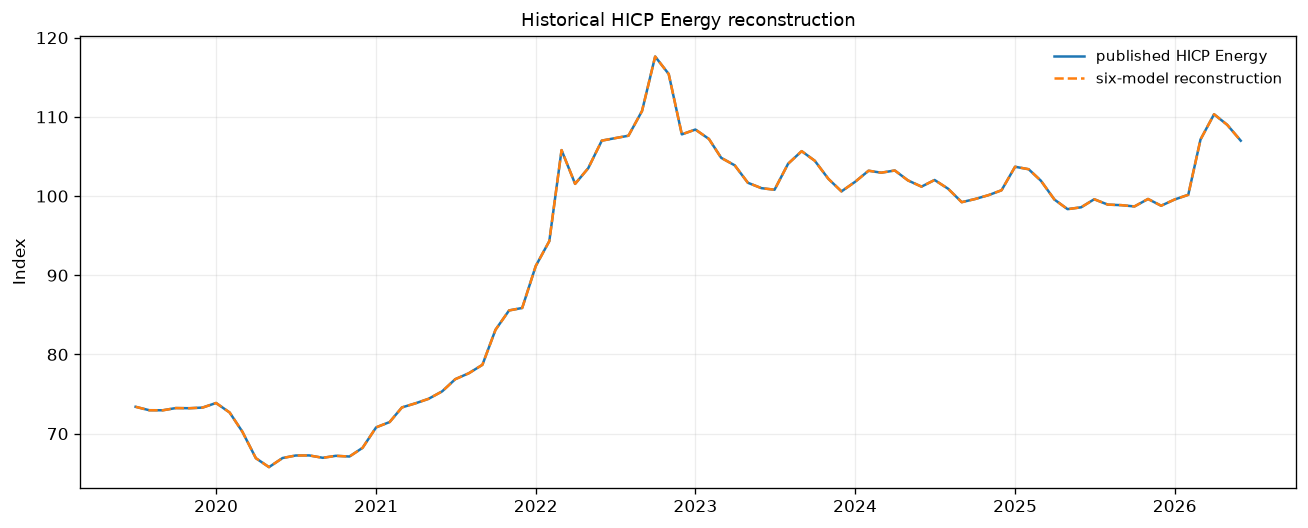

In [5]:

aggregation_inputs = load_aggregation_inputs(PROCESSED_DIR)
indices = aggregation_inputs["indices"]
weights = aggregation_inputs["weights"]

historical_validation = historical_reconstruction_suite(PROCESSED_DIR)
model_history = historical_model_component_reconstruction(PROCESSED_DIR)

# Always show every cumulative and annual re-anchored test before the hard gate.
display(historical_validation["summary"])
display(model_history["summary"])

# The hard gate is the annual re-anchored reconstruction. Long chained
# error remains visible as a rounding-drift diagnostic.
assert_reconstruction_suite(historical_validation)
assert_reconstruction_suite(model_history)

published_energy = indices["hicp_energy"].dropna()
reconstructed_energy = model_history["energy"]["index"]

comparison = pd.concat(
    [
        published_energy.rename("published HICP Energy"),
        reconstructed_energy.rename("six-model reconstruction"),
    ],
    axis=1,
).dropna()

fig, ax = plt.subplots(figsize=(11, 4.5))
shown = comparison.iloc[-84:]
ax.plot(shown.index, shown.iloc[:, 0], label=shown.columns[0])
ax.plot(shown.index, shown.iloc[:, 1], linestyle="--", label=shown.columns[1])
ax.set_title("Historical HICP Energy reconstruction")
ax.set_ylabel("Index")
ax.grid(alpha=0.22)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()



## 3. Load the seven posterior predictive stores

Every store contains the **full draw-by-date level paths**, not only a median and fan quantiles.


In [6]:

forecasts = {
    name: load_energy_bvar_forecast(path)
    for name, path in FORECAST_STORES.items()
}

forecast_contract_rows = []
for name, forecast in forecasts.items():
    paths = np.asarray(forecast["level_paths"], dtype=float)
    dates = pd.DatetimeIndex(forecast["path_dates"])
    forecast_contract_rows.append({
        "model": name,
        "frequency": forecast["frequency"],
        "draws": paths.shape[0],
        "path_start": dates.min(),
        "path_end": dates.max(),
        "future_start": pd.DatetimeIndex(forecast["future_dates"]).min(),
        "future_end": pd.DatetimeIndex(forecast["future_dates"]).max(),
        "tail_length": int(forecast["tail_length"]),
        "variables": " | ".join(forecast["variables"]),
    })

forecast_contract = pd.DataFrame(forecast_contract_rows).set_index("model")
display(forecast_contract)

assert forecasts["gas"]["frequency"] == "monthly"
assert forecasts["electricity"]["frequency"] == "monthly"
assert forecasts["heat_energy"]["frequency"] == "monthly"
assert forecasts["solid_fuels"]["frequency"] == "monthly"
assert forecasts["petrol"]["frequency"] == "weekly"
assert forecasts["diesel"]["frequency"] == "weekly"
assert forecasts["liquid_fuels"]["frequency"] == "weekly"


,frequency,draws,path_start,path_end,future_start,future_end,tail_length,variables
model,,,,,,,,
gas,monthly,1000,2026-07-01,2026-12-01,2026-09-01,2026-12-01,2,natural_gas_wholesale | gas_pre_tax
electricity,monthly,1000,2026-07-01,2026-12-01,2026-09-01,2026-12-01,2,natural_gas_wholesale | electricity_pre_tax
heat_energy,monthly,1000,2026-07-01,2026-12-01,2026-09-01,2026-12-01,2,natural_gas_wholesale | ppi_energy | hicp_heat...
solid_fuels,monthly,1000,2026-07-01,2026-12-01,2026-09-01,2026-12-01,2,natural_gas_wholesale | ppi_energy | hicp_soli...
petrol,weekly,500,2026-08-10,2027-02-08,2026-08-17,2027-02-08,1,wob_petrol_pre_tax | crude_oil_eur | refined_p...
diesel,weekly,500,2026-08-10,2027-02-08,2026-08-17,2027-02-08,1,wob_diesel_pre_tax | crude_oil_eur | refined_d...
liquid_fuels,weekly,500,2026-08-10,2027-02-08,2026-08-17,2027-02-08,1,wob_heating_oil_pre_tax | crude_oil_eur | refi...



## 4. Gas and electricity: exact tax re-attribution

For these two components the processed-vintage manifest already contains the estimated \(\gamma\), while Eurostat supplies VAT and excise. The historical round trip

\[
HICP \rightarrow P^{pre-tax}\rightarrow HICP
\]

must remain exact before forecast paths are used.


In [7]:

gas_dataset = PROCESSED_DIR / DATASET_FILES["gas"]
electricity_dataset = PROCESSED_DIR / DATASET_FILES["electricity"]

gas_tax_context = load_gas_tax_context(gas_dataset)
electricity_tax_context = load_electricity_tax_context(electricity_dataset)

display(validate_tax_round_trip(gas_tax_context).to_frame("gas"))
display(validate_electricity_tax_round_trip(electricity_tax_context).to_frame("electricity"))


def _scenario_values(value, dates: pd.DatetimeIndex, label: str) -> np.ndarray:
    if isinstance(value, pd.Series):
        series = value.astype(float).copy()
        series.index = pd.DatetimeIndex(series.index).to_period("M").to_timestamp(how="start")
        if series.index.has_duplicates:
            raise ValueError(f"{label}: duplicate scenario months.")
        array = series.reindex(dates).to_numpy(dtype=float)
    else:
        array = np.asarray(value, dtype=float)
        if array.ndim == 0:
            array = np.repeat(float(array), len(dates))
    if array.ndim != 1 or len(array) != len(dates):
        raise ValueError(f"{label}: expected scalar, dated Series or length {len(dates)}.")
    if not np.all(np.isfinite(array)):
        raise ValueError(f"{label}: scenario contains non-finite values.")
    return array


def _apply_monthly_scenario(
    baseline_vat: pd.Series,
    baseline_excise: pd.Series,
    scenario: dict | None,
    *,
    excise_unit: str,
) -> tuple[pd.Series, pd.Series]:
    vat = baseline_vat.astype(float).copy()
    excise = baseline_excise.astype(float).copy()
    if scenario is None:
        return vat, excise

    scenario = dict(scenario)
    if "start_date" not in scenario:
        raise ValueError("Monthly tax scenario requires 'start_date'.")
    if "vat_percent" not in scenario and "excise" not in scenario:
        raise ValueError("Monthly tax scenario must change VAT and/or excise.")

    start = pd.Timestamp(scenario["start_date"]).to_period("M").to_timestamp(how="start")
    active_dates = vat.index[vat.index >= start]
    if len(active_dates) == 0:
        raise ValueError(f"Tax scenario starts after the forecast path: {start.date()}.")

    if "vat_percent" in scenario:
        values = _scenario_values(scenario["vat_percent"], active_dates, "vat_percent")
        if np.any((values < 0) | (values > 100)) or np.any((values > 0) & (values < 1)):
            raise ValueError("VAT must be supplied in percentage points, e.g. 21.0.")
        vat.loc[active_dates] = values

    if "excise" in scenario:
        supplied = scenario.get("excise_unit")
        if supplied is None:
            raise ValueError(f"Excise scenario requires excise_unit={excise_unit!r}.")
        norm = lambda x: "".join(str(x).lower().split())
        if norm(supplied) != norm(excise_unit):
            raise ValueError(
                f"Excise unit mismatch: expected {excise_unit!r}, got {supplied!r}."
            )
        excise.loc[active_dates] = _scenario_values(
            scenario["excise"], active_dates, "excise"
        )

    return vat, excise


def monthly_pretax_forecast_to_hicp(
    forecast: dict,
    *,
    target_variable: str,
    tax_context: dict,
    expand_function,
    reattribute_function,
    tax_scenario: dict | None,
) -> dict:
    dates = pd.DatetimeIndex(forecast["path_dates"], name="date")
    variables = list(forecast["variables"])
    if target_variable not in variables:
        raise KeyError(f"{target_variable!r} absent from {variables}.")

    j = variables.index(target_variable)
    pre_tax = np.asarray(forecast["level_paths"], dtype=float)[:, :, j]

    baseline_vat = expand_function(tax_context["vat_percent"], dates)
    baseline_excise = expand_function(tax_context["excise"], dates)

    scenario_vat, scenario_excise = _apply_monthly_scenario(
        baseline_vat,
        baseline_excise,
        tax_scenario,
        excise_unit=str(tax_context["excise_unit"]),
    )

    baseline = reattribute_function(
        pre_tax,
        float(tax_context["gamma"]),
        baseline_vat.to_numpy(dtype=float)[None, :],
        baseline_excise.to_numpy(dtype=float)[None, :],
    )
    scenario = reattribute_function(
        pre_tax,
        float(tax_context["gamma"]),
        scenario_vat.to_numpy(dtype=float)[None, :],
        scenario_excise.to_numpy(dtype=float)[None, :],
    )
    return {
        "dates": dates,
        "baseline": np.asarray(baseline, dtype=float),
        "scenario": np.asarray(scenario, dtype=float),
    }


gas_hicp = monthly_pretax_forecast_to_hicp(
    forecasts["gas"],
    target_variable="gas_pre_tax",
    tax_context=gas_tax_context,
    expand_function=expand_gas_semester_series,
    reattribute_function=reattribute_gas_taxes,
    tax_scenario=TAX_SCENARIOS["gas"],
)

electricity_hicp = monthly_pretax_forecast_to_hicp(
    forecasts["electricity"],
    target_variable="electricity_pre_tax",
    tax_context=electricity_tax_context,
    expand_function=expand_electricity_semester_series,
    reattribute_function=reattribute_electricity_taxes,
    tax_scenario=TAX_SCENARIOS["electricity"],
)

print("Gas/electricity HICP paths ready.")


,gas
observations,2.760000e+02
maximum_absolute_error,2.842171e-14
tolerance,1.000000e-10


,electricity
observations,2.760000e+02
maximum_absolute_error,2.842171e-14
tolerance,1.000000e-10


Gas/electricity HICP paths ready.



## 5. Heat energy and solid fuels

These BVAR targets are already HICP indices. No tax bridge is required.


In [8]:

def direct_hicp_paths(forecast: dict, target: str) -> dict:
    variables = list(forecast["variables"])
    if target not in variables:
        raise KeyError(f"{target!r} absent from {variables}.")
    j = variables.index(target)
    return {
        "dates": pd.DatetimeIndex(forecast["path_dates"], name="date"),
        "baseline": np.asarray(forecast["level_paths"], dtype=float)[:, :, j],
        "scenario": np.asarray(forecast["level_paths"], dtype=float)[:, :, j],
    }


heat_hicp = direct_hicp_paths(
    forecasts["heat_energy"],
    "hicp_heat_energy",
)
solid_hicp = direct_hicp_paths(
    forecasts["solid_fuels"],
    "hicp_solid_fuels",
)

print("Heat-energy and solid-fuels HICP paths ready.")


Heat-energy and solid-fuels HICP paths ready.



## 6. Petrol, diesel and liquid fuels: WOB consumer prices as HICP price relatives

The paper does **not** specify an estimated regression mapping from WOB consumer prices to HICP indices. For car fuels it states that the weekly petrol and diesel price forecasts are converted to monthly frequency and aggregated using their weights; liquid fuels use the same weekly WOB setup.

Accordingly, this notebook does **not** propagate an estimated bridge coefficient. After taxes have been re-attributed, the monthly WOB consumer-price path is used as a price relative and rebased to the latest month in which both WOB and the published HICP sub-index are observed:

\[
\widetilde I_t
=
I_a^{HICP}\frac{P_t^{WOB}}{P_a^{WOB}},
\]

where \(a\) is the latest common pre-path month.

The scale of the WOB price is irrelevant for Laspeyres aggregation; what matters is its relative movement.

The notebook still diagnoses the proxy before using it. In particular it reports:

\[
\Delta\log HICP_t
=
\beta\,\Delta\log WOB_t+\varepsilon_t
\]

as a **diagnostic only**, where the proportional benchmark is \(\beta=1\), together with the recent stability of the level ratio \(HICP_t/WOB_t\). It also reports the level-residual drift that invalidated the previous absolute-difference regression bridge.

Production mode is `WEEKLY_TAX_MODE="strict"`: WOB VAT and excise must be available so the BVAR pre-tax forecasts can first be converted back to consumer prices. A pre-tax proxy fallback exists only for exploration and is not accepted silently.


In [9]:

WEEKLY_MODELS = ("petrol", "diesel", "liquid_fuels")
WEEKLY_HICP_COLUMNS = {
    "petrol": "hicp_petrol",
    "diesel": "hicp_diesel",
    "liquid_fuels": "hicp_liquid_fuels",
}
WEEKLY_TARGETS = {
    "petrol": "wob_petrol_pre_tax",
    "diesel": "wob_diesel_pre_tax",
    "liquid_fuels": "wob_heating_oil_pre_tax",
}
WEEKLY_DATASETS = {
    "petrol": PROCESSED_DIR / "car_fuels_weekly.csv",
    "diesel": PROCESSED_DIR / "car_fuels_weekly.csv",
    "liquid_fuels": PROCESSED_DIR / "liquid_fuels_weekly.csv",
}

EC_RENAME = {
    "EUR_price_with_tax_euro95": "wob_petroleum_cpr_wtax",
    "EUR_price_wo_tax_euro95": "wob_petroleum_cpr_ntax",
    "EUR_price_with_tax_diesel": "wob_diesel_cpr_wtax",
    "EUR_price_wo_tax_diesel": "wob_diesel_cpr_ntax",
    "EUR_price_with_tax_heating_oil": "wob_gas_cpr_wtax",
    "EUR_price_wo_tax_heating_oil": "wob_gas_cpr_ntax",
}
FALLBACK_PRETAX_COLUMNS = {
    "petrol": "wob_petroleum_cpr_ntax",
    "diesel": "wob_diesel_cpr_ntax",
    "liquid_fuels": "wob_gas_cpr_ntax",
}

if WEEKLY_TAX_MODE not in {"strict", "pre_tax_proxy_fallback"}:
    raise ValueError(
        "WEEKLY_TAX_MODE must be 'strict' or 'pre_tax_proxy_fallback'."
    )


def monthly_mean_series(series: pd.Series) -> pd.Series:
    series = series.astype(float).dropna().sort_index()
    grouped = series.groupby(series.index.to_period("M")).mean()
    grouped.index = grouped.index.to_timestamp(how="start")
    grouped.index = pd.DatetimeIndex(grouped.index, name="date")
    return grouped


def carry_to_dates(series: pd.Series, dates: pd.DatetimeIndex) -> np.ndarray:
    observed = series.astype(float).dropna().sort_index()
    union = observed.index.union(dates).sort_values()
    carried = observed.reindex(union).ffill().reindex(dates)
    if carried.isna().any():
        raise ValueError(
            f"No observation for {series.name!r} exists on/before "
            f"{carried.index[carried.isna()][0].date()}."
        )
    return carried.to_numpy(dtype=float)


def weekly_tax_scenario_kwargs(
    forecast: dict,
    context: dict,
    scenario: dict | None,
) -> dict:
    """Translate Notebook-10 tax scenario syntax into the weekly adapter contract."""
    if scenario is None:
        return {}

    scenario = dict(scenario)
    if "start_date" not in scenario:
        raise ValueError("Weekly tax scenario requires 'start_date'.")

    future_dates = pd.DatetimeIndex(forecast["future_dates"], name="date")
    vat = carry_to_dates(context["data"]["vat_percent"], future_dates)
    excise = carry_to_dates(context["data"]["excise"], future_dates)

    start = pd.Timestamp(scenario["start_date"])
    active = future_dates >= start
    if not active.any():
        raise ValueError(
            f"Weekly tax scenario starts after the forecast path: {start.date()}."
        )

    if "vat_percent" in scenario:
        value = np.asarray(scenario["vat_percent"], dtype=float)
        if value.ndim == 0:
            vat[active] = float(value)
        else:
            if value.ndim != 1 or len(value) != int(active.sum()):
                raise ValueError(
                    "Weekly vat_percent must be scalar or have one value per "
                    "active future week."
                )
            vat[active] = value

    if "excise" in scenario:
        value = np.asarray(scenario["excise"], dtype=float)
        if value.ndim == 0:
            excise[active] = float(value)
        else:
            if value.ndim != 1 or len(value) != int(active.sum()):
                raise ValueError(
                    "Weekly excise must be scalar or have one value per "
                    "active future week."
                )
            excise[active] = value

    return {
        "future_vat_percent": vat,
        "future_excise": excise,
    }


# The loaded WOB view is useful both for diagnostics and for the deliberately
# explicit pre-tax fallback.
wob_price_frame, wob_price_source = load_manifest_source_frame(
    PROCESSED_DIR / "car_fuels_weekly.csv",
    "european_commission",
    simple_rename=EC_RENAME,
)
wob_price_frame.index = pd.DatetimeIndex(
    wob_price_frame.index
).to_period("W-SUN").start_time
wob_price_frame.index.name = "date"

weekly_tax_contexts = {}
weekly_tax_errors = {}
weekly_monthly_coverage = {}
proxy_diagnostics = {}
weekly_hicp_paths = {}
weekly_price_basis = {}
weekly_price_draw_filter = {}

if WEEKLY_TAX_MODE == "strict":
    for model in WEEKLY_MODELS:
        try:
            weekly_tax_contexts[model] = load_weekly_tax_context(
                WEEKLY_DATASETS[model],
                model=model,
            )
        except (FileNotFoundError, KeyError, ValueError) as exc:
            weekly_tax_errors[model] = str(exc)

    if weekly_tax_errors:
        display(pd.Series(weekly_tax_errors, name="WOB tax-context error"))
        raise RuntimeError(
            "Notebook 10 production mode requires the separate WOB VAT and IDT "
            "series for petrol, diesel and liquid fuels. The current source "
            "contract is incomplete; no pre-tax→HICP regression fallback is "
            "used automatically."
        )

    WEEKLY_TAX_MODE_EFFECTIVE = "official_wob_tax_reattribution"

else:
    WEEKLY_TAX_MODE_EFFECTIVE = "pre_tax_proxy_fallback"
    warnings.warn(
        "Using pre-tax WOB price relatives as HICP proxies. This is an "
        "exploratory approximation, not the paper-faithful tax treatment.",
        RuntimeWarning,
    )

for model in WEEKLY_MODELS:
    forecast = forecasts[model]
    target = WEEKLY_TARGETS[model]
    variables = list(forecast["variables"])
    if target not in variables:
        raise KeyError(f"{model}: {target!r} absent from {variables}.")
    j = variables.index(target)

    if WEEKLY_TAX_MODE_EFFECTIVE == "official_wob_tax_reattribution":
        context = weekly_tax_contexts[model]

        baseline_taxed = reattribute_weekly_taxes(
            forecast,
            context,
        )
        scenario_kwargs = weekly_tax_scenario_kwargs(
            forecast,
            context,
            TAX_SCENARIOS[model],
        )
        scenario_taxed = reattribute_weekly_taxes(
            forecast,
            context,
            **scenario_kwargs,
        )

        # The BVAR forecasts the pre-tax price. It must be admissible itself;
        # positive taxes are not allowed to "rescue" a negative pre-tax draw.
        admissibility_paths = {
            "pre_tax_weekly": np.asarray(
                baseline_taxed["pre_tax_level_paths"], dtype=float
            ),
            "baseline_after_tax_weekly": np.asarray(
                baseline_taxed["post_tax_level_paths"], dtype=float
            ),
            "scenario_after_tax_weekly": np.asarray(
                scenario_taxed["post_tax_level_paths"], dtype=float
            ),
        }

        baseline_monthly, monthly_dates, baseline_coverage = (
            weekly_paths_with_history_to_monthly_mean(
                baseline_taxed["post_tax_level_paths"],
                baseline_taxed["path_dates"],
                context["data"]["after_tax"],
                return_coverage=True,
            )
        )
        scenario_monthly, scenario_dates, scenario_coverage = (
            weekly_paths_with_history_to_monthly_mean(
                scenario_taxed["post_tax_level_paths"],
                scenario_taxed["path_dates"],
                context["data"]["after_tax"],
                return_coverage=True,
            )
        )
        if not monthly_dates.equals(scenario_dates):
            raise RuntimeError(
                f"{model}: baseline/scenario monthly calendars differ."
            )
        if not baseline_coverage.equals(scenario_coverage):
            raise RuntimeError(
                f"{model}: baseline/scenario monthly coverage differs."
            )

        historical_price = context["data"]["after_tax"]
        weekly_price_basis[model] = "after-tax WOB consumer price"

    else:
        if TAX_SCENARIOS[model] is not None:
            raise RuntimeError(
                f"{model}: tax scenarios are unavailable in pre-tax proxy fallback mode."
            )

        historical_price = wob_price_frame[
            FALLBACK_PRETAX_COLUMNS[model]
        ].astype(float)
        pre_tax_paths = np.asarray(
            forecast["level_paths"], dtype=float
        )[:, :, j]

        baseline_monthly, monthly_dates, baseline_coverage = (
            weekly_paths_with_history_to_monthly_mean(
                pre_tax_paths,
                forecast["path_dates"],
                historical_price,
                return_coverage=True,
            )
        )
        scenario_monthly = baseline_monthly.copy()
        scenario_dates = monthly_dates
        scenario_coverage = baseline_coverage
        admissibility_paths = {
            "pre_tax_weekly": pre_tax_paths,
        }
        weekly_price_basis[model] = "pre-tax WOB price — exploratory fallback"

    weekly_monthly_coverage[model] = baseline_coverage

    hicp_history = indices[WEEKLY_HICP_COLUMNS[model]]
    historical_monthly_price = monthly_mean_series(historical_price)

    diagnostic = price_proxy_diagnostics(
        historical_monthly_price,
        hicp_history,
        label=f"{model}: {weekly_price_basis[model]} vs HICP",
    )
    proxy_diagnostics[model] = diagnostic

    if (
        WEEKLY_TAX_MODE_EFFECTIVE == "pre_tax_proxy_fallback"
        and not diagnostic.proxy_quality_pass
        and not ALLOW_WEAK_PRETAX_PROXY_FALLBACK
    ):
        raise AssertionError(
            f"{model}: pre-tax WOB/HICP proxy diagnostics failed: "
            f"{diagnostic.proxy_quality_note}. Restore the WOB VAT/IDT series "
            "for the production aggregation."
        )

    price_filter = filter_positive_price_draws(
        baseline_monthly,
        scenario_monthly,
        admissibility_paths=admissibility_paths,
        max_rejection_rate=None,
        label=model,
    )
    baseline_monthly = price_filter["baseline_paths"]
    scenario_monthly = price_filter["scenario_paths"]
    weekly_price_draw_filter[model] = price_filter["diagnostics"]

    filter_diag = price_filter["diagnostics"]
    print(
        f"{model}: positive-price filter retained "
        f"{filter_diag['retained_draws']}/{filter_diag['total_draws']} draws; "
        f"rejected {filter_diag['rejected_draws']} "
        f"({100.0 * filter_diag['rejection_rate']:.2f}%)."
    )

    baseline_rebased = rebase_price_paths_to_hicp_index(
        baseline_monthly,
        monthly_dates,
        historical_monthly_price,
        hicp_history,
    )
    scenario_rebased = rebase_price_paths_to_hicp_index(
        scenario_monthly,
        scenario_dates,
        historical_monthly_price,
        hicp_history,
    )

    if not baseline_rebased["dates"].equals(scenario_rebased["dates"]):
        raise RuntimeError(
            f"{model}: baseline/scenario HICP-proxy calendars differ."
        )
    if baseline_rebased["anchor_date"] != scenario_rebased["anchor_date"]:
        raise RuntimeError(
            f"{model}: baseline/scenario HICP-proxy anchors differ."
        )

    weekly_hicp_paths[model] = {
        "dates": baseline_rebased["dates"],
        "baseline": baseline_rebased["index_paths"],
        "scenario": scenario_rebased["index_paths"],
        "anchor_date": baseline_rebased["anchor_date"],
        "anchor_price": baseline_rebased["anchor_price"],
        "anchor_hicp": baseline_rebased["anchor_hicp"],
        "method": baseline_rebased["method"],
        "retained_original_draw_indices": price_filter["draw_indices"],
    }

proxy_table = price_proxy_diagnostic_table(proxy_diagnostics)
proxy_table["price_basis"] = pd.Series(weekly_price_basis)
display(proxy_table)

print("Predictive price-admissibility filter (fan is conditional on retained paths):")
display(pd.DataFrame(weekly_price_draw_filter).T)

print("Weekly-to-monthly coverage diagnostics:")
for model in WEEKLY_MODELS:
    print(f"\n{model}")
    display(weekly_monthly_coverage[model])

for model in WEEKLY_MODELS:
    obj = weekly_hicp_paths[model]
    print(
        f"{model:13s}: {obj['dates'].min().date()} -> "
        f"{obj['dates'].max().date()} | "
        f"{obj['baseline'].shape[0]} draws | "
        f"anchor={obj['anchor_date'].date()}"
    )

C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\src\model\energy_bvar_aggregate.py:1234: RuntimeWarning: Dropping incomplete final weekly-to-monthly aggregate 2027-02: 2/4 Mondays available.
  warnings.warn(
C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\src\model\energy_bvar_aggregate.py:1234: RuntimeWarning: Dropping incomplete final weekly-to-monthly aggregate 2027-02: 2/4 Mondays available.
  warnings.warn(


petrol: positive-price filter retained 487/500 draws; rejected 13 (2.60%).


C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\src\model\energy_bvar_aggregate.py:1234: RuntimeWarning: Dropping incomplete final weekly-to-monthly aggregate 2027-02: 2/4 Mondays available.
  warnings.warn(
C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\src\model\energy_bvar_aggregate.py:1234: RuntimeWarning: Dropping incomplete final weekly-to-monthly aggregate 2027-02: 2/4 Mondays available.
  warnings.warn(


diesel: positive-price filter retained 483/500 draws; rejected 17 (3.40%).
liquid_fuels: positive-price filter retained 476/500 draws; rejected 24 (4.80%).


C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\src\model\energy_bvar_aggregate.py:1234: RuntimeWarning: Dropping incomplete final weekly-to-monthly aggregate 2027-02: 2/4 Mondays available.
  warnings.warn(
C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\src\model\energy_bvar_aggregate.py:1234: RuntimeWarning: Dropping incomplete final weekly-to-monthly aggregate 2027-02: 2/4 Mondays available.
  warnings.warn(


...


diesel


,expected_mondays,observed_history_mondays,simulated_mondays,available_mondays,complete,retained
date,,,,,,
2026-08-01,5,1,4,5,True,True
2026-09-01,4,0,4,4,True,True
2026-10-01,4,0,4,4,True,True
2026-11-01,5,0,5,5,True,True
2026-12-01,4,0,4,4,True,True
2027-01-01,4,0,4,4,True,True
2027-02-01,4,0,2,2,False,False



liquid_fuels


,expected_mondays,observed_history_mondays,simulated_mondays,available_mondays,complete,retained
date,,,,,,
2026-08-01,5,1,4,5,True,True
2026-09-01,4,0,4,4,True,True
2026-10-01,4,0,4,4,True,True
2026-11-01,5,0,5,5,True,True
2026-12-01,4,0,4,4,True,True
2027-01-01,4,0,4,4,True,True
2027-02-01,4,0,2,2,False,False


petrol       : 2026-07-01 -> 2027-01-01 | 487 draws | anchor=2026-06-01
diesel       : 2026-07-01 -> 2027-01-01 | 483 draws | anchor=2026-06-01
liquid_fuels : 2026-07-01 -> 2027-01-01 | 476 draws | anchor=2026-06-01



## 7. Build the energy-relevant car-fuels index

For HICP Energy the transport block excludes lubricants. The forecasted car-fuels basket is therefore

\[
\{\text{diesel},\ \text{petrol},\ \text{other transport fuels}\}.
\]

`Other transport fuels` has no dedicated BVAR in the paper suite. Its latest published HICP level is held constant over the short forecast horizon. Its raw HICP weight remains in the Laspeyres aggregation, so it is not silently dropped.


In [10]:

def common_monthly_dates(objects: list[dict]) -> pd.DatetimeIndex:
    common = None
    for obj in objects:
        dates = pd.DatetimeIndex(obj["dates"], name="date")
        common = dates if common is None else common.intersection(dates)
    if common is None or len(common) == 0:
        raise ValueError("No common monthly aggregation dates.")
    common = pd.DatetimeIndex(common.sort_values(), name="date")
    expected = pd.date_range(common[0], common[-1], freq="MS", name="date")
    if not common.equals(expected):
        raise ValueError("The common monthly path contains an interior gap.")
    return common


def align_paths(obj: dict, key: str, dates: pd.DatetimeIndex) -> np.ndarray:
    source_dates = pd.DatetimeIndex(obj["dates"], name="date")
    positions = source_dates.get_indexer(dates)
    if (positions < 0).any():
        raise ValueError("Requested dates are absent from a component path.")
    return np.asarray(obj[key], dtype=float)[:, positions]


transport_dates = common_monthly_dates([
    weekly_hicp_paths["petrol"],
    weekly_hicp_paths["diesel"],
])

petrol_base = align_paths(weekly_hicp_paths["petrol"], "baseline", transport_dates)
diesel_base = align_paths(weekly_hicp_paths["diesel"], "baseline", transport_dates)
petrol_scenario = align_paths(weekly_hicp_paths["petrol"], "scenario", transport_dates)
diesel_scenario = align_paths(weekly_hicp_paths["diesel"], "scenario", transport_dates)

transport_pool_sizes = {
    "hicp_petrol": int(petrol_base.shape[0]),
    "hicp_diesel": int(diesel_base.shape[0]),
}
N_TRANSPORT_DRAWS = min(
    int(N_AGG_DRAWS),
    *transport_pool_sizes.values(),
)
if N_TRANSPORT_DRAWS < 1:
    raise RuntimeError("No admissible petrol/diesel draws remain for car-fuels aggregation.")

other_transport = carry_last_index_path(
    indices["hicp_other_transport_fuels"],
    transport_dates,
    n_draws=N_TRANSPORT_DRAWS,
)

transport_base_unpaired = {
    "hicp_petrol": petrol_base,
    "hicp_diesel": diesel_base,
    "hicp_other_transport_fuels": other_transport,
}

transport_base_paired, transport_pair_indices = independent_draw_pairing(
    transport_base_unpaired,
    n_draws=N_TRANSPORT_DRAWS,
    seed=PAIRING_SEED,
)

transport_scenario_paired = {
    "hicp_petrol": petrol_scenario[transport_pair_indices["hicp_petrol"]],
    "hicp_diesel": diesel_scenario[transport_pair_indices["hicp_diesel"]],
    "hicp_other_transport_fuels": other_transport[
        transport_pair_indices["hicp_other_transport_fuels"]
    ],
}

transport_components = [
    "hicp_diesel",
    "hicp_petrol",
    "hicp_other_transport_fuels",
]
transport_weights = weights[transport_components]

transport_history_index = pd.concat(
    [
        pd.Series(
            [100.0],
            index=pd.DatetimeIndex([pd.Timestamp("2016-12-01")], name="date"),
        ),
        model_history["transport_energy"]["index"],
    ]
).sort_index()
transport_history_index.name = "car_fuels"

transport_component_history = indices[transport_components]

car_fuels_baseline = aggregate_component_draw_paths_laspeyres(
    transport_component_history,
    transport_base_paired,
    transport_dates,
    transport_weights,
    transport_history_index,
    components=transport_components,
)

car_fuels_scenario = aggregate_component_draw_paths_laspeyres(
    transport_component_history,
    transport_scenario_paired,
    transport_dates,
    transport_weights,
    transport_history_index,
    components=transport_components,
)

assert np.array_equal(
    car_fuels_baseline["weight_year_used"].to_numpy(),
    car_fuels_scenario["weight_year_used"].to_numpy(),
)

print(
    f"Car-fuels path: {transport_dates.min().date()} -> "
    f"{transport_dates.max().date()} | {N_TRANSPORT_DRAWS} matched draws "
    f"(pool sizes: {transport_pool_sizes})"
)


Car-fuels path: 2026-07-01 -> 2027-01-01 | 483 matched draws (pool sizes: {'hicp_petrol': 487, 'hicp_diesel': 483})



## 8. Aggregate the six model components into HICP Energy

The six blocks are:

\[
\text{Car fuels},\quad
\text{Liquid fuels},\quad
\text{Gas},\quad
\text{Electricity},\quad
\text{Heat energy},\quad
\text{Solid fuels}.
\]

The final aggregation is performed **draw by draw**. Annual raw Eurostat weights are normalised only inside HICP Energy. If the horizon crosses into a year for which new weights have not yet been published, the latest available annual weight vector is carried forward and the weight year used is stored.


In [11]:

component_objects = {
    "car_fuels": {
        "dates": transport_dates,
        "baseline": car_fuels_baseline["level_paths"],
        "scenario": car_fuels_scenario["level_paths"],
    },
    "liquid_fuels": weekly_hicp_paths["liquid_fuels"],
    "gas": gas_hicp,
    "electricity": electricity_hicp,
    "heat_energy": heat_hicp,
    "solid_fuels": solid_hicp,
}

aggregate_dates = common_monthly_dates(list(component_objects.values()))

baseline_unpaired = {
    name: align_paths(obj, "baseline", aggregate_dates)
    for name, obj in component_objects.items()
}
scenario_unpaired = {
    name: align_paths(obj, "scenario", aggregate_dates)
    for name, obj in component_objects.items()
}

final_component_pool_sizes = {
    name: int(paths.shape[0])
    for name, paths in baseline_unpaired.items()
}
N_AGG_DRAWS_EFFECTIVE = min(
    int(N_AGG_DRAWS),
    *final_component_pool_sizes.values(),
)
if N_AGG_DRAWS_EFFECTIVE < 1:
    raise RuntimeError("No common admissible draw pool remains for HICP Energy aggregation.")

baseline_components, final_pair_indices = independent_draw_pairing(
    baseline_unpaired,
    n_draws=N_AGG_DRAWS_EFFECTIVE,
    seed=PAIRING_SEED + 1,
)

scenario_components = {
    name: scenario_unpaired[name][final_pair_indices[name]]
    for name in baseline_components
}

energy_baseline = aggregate_draw_paths_laspeyres(
    model_history["component_history"],
    baseline_components,
    aggregate_dates,
    weights,
    indices["hicp_energy"],
)

energy_scenario = aggregate_draw_paths_laspeyres(
    model_history["component_history"],
    scenario_components,
    aggregate_dates,
    weights,
    indices["hicp_energy"],
)

energy_baseline_yoy = draw_yoy_and_contributions(
    energy_baseline,
    model_history["energy"],
)
energy_scenario_yoy = draw_yoy_and_contributions(
    energy_scenario,
    model_history["energy"],
)

print(
    f"HICP Energy aggregate path: {aggregate_dates.min().date()} -> "
    f"{aggregate_dates.max().date()}"
)
print(f"Requested aggregate draw cap: {N_AGG_DRAWS}")
print(f"Effective aggregate draws:     {N_AGG_DRAWS_EFFECTIVE}")
print(f"Component retained pools:      {final_component_pool_sizes}")
display(
    energy_baseline["weight_year_used"]
    .rename("Eurostat weight year used")
    .to_frame()
)


HICP Energy aggregate path: 2026-07-01 -> 2026-12-01
Requested aggregate draw cap: 500
Effective aggregate draws:     476
Component retained pools:      {'car_fuels': 483, 'liquid_fuels': 476, 'gas': 1000, 'electricity': 1000, 'heat_energy': 1000, 'solid_fuels': 1000}


,Eurostat weight year used
date,
2026-07-01,2026
2026-08-01,2026
2026-09-01,2026
2026-10-01,2026
2026-11-01,2026
2026-12-01,2026



## 9. HICP Energy forecast fan

The median is computed **after** draw-wise aggregation. It is therefore not a weighted average of component medians.


,q05,q16,q50,q84,q95
date,,,,,
2026-07-01,109.399812,109.811516,110.127842,110.549498,110.985799
2026-08-01,109.854943,110.703033,111.838860,112.965437,114.540062
2026-09-01,106.138661,108.406593,111.437131,114.877476,118.316615
2026-10-01,104.145493,107.162639,111.937314,116.950582,120.908370
2026-11-01,102.564505,106.625925,112.478425,118.611194,124.539806
2026-12-01,101.161444,106.064686,112.511441,120.847405,128.104614


,q05,q16,q50,q84,q95
date,,,,,
2026-07-01,9.843182,10.256554,10.574163,10.997528,11.435596
2026-08-01,11.050977,11.908301,13.056494,14.195336,15.787104
2026-09-01,7.368976,9.663196,12.728863,16.209087,19.688092
2026-10-01,5.525499,8.582624,13.420567,18.500265,22.510497
2026-11-01,2.942294,7.018675,12.892732,19.048090,24.998539
2026-12-01,2.406776,7.370379,13.896496,22.335078,29.681625


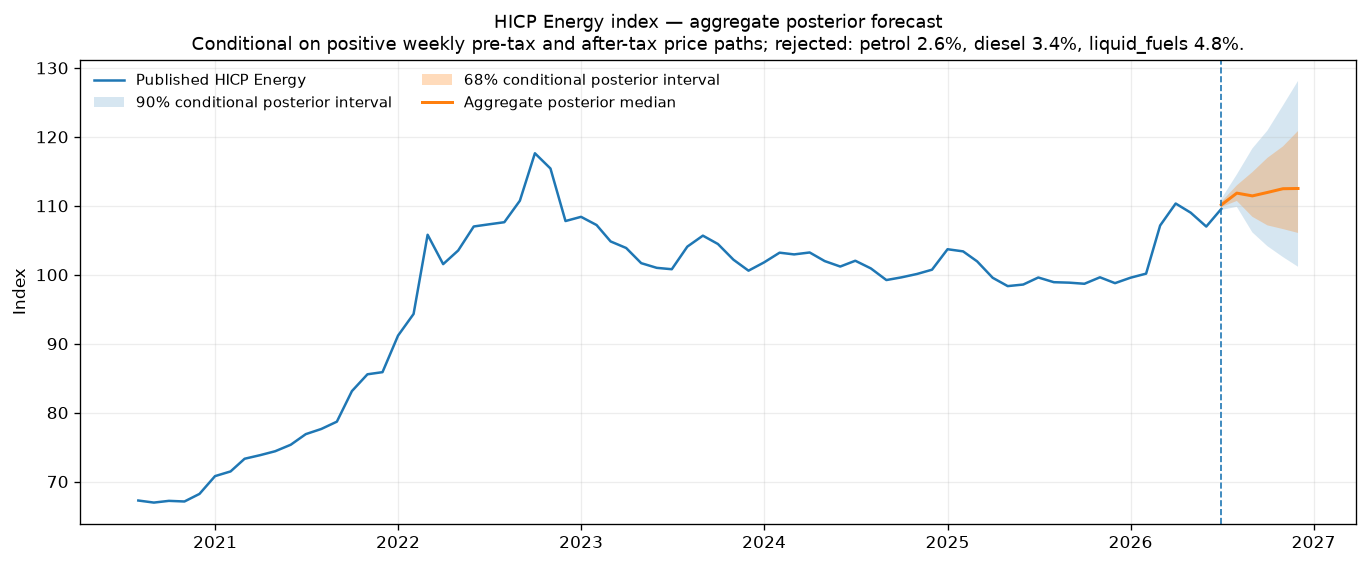

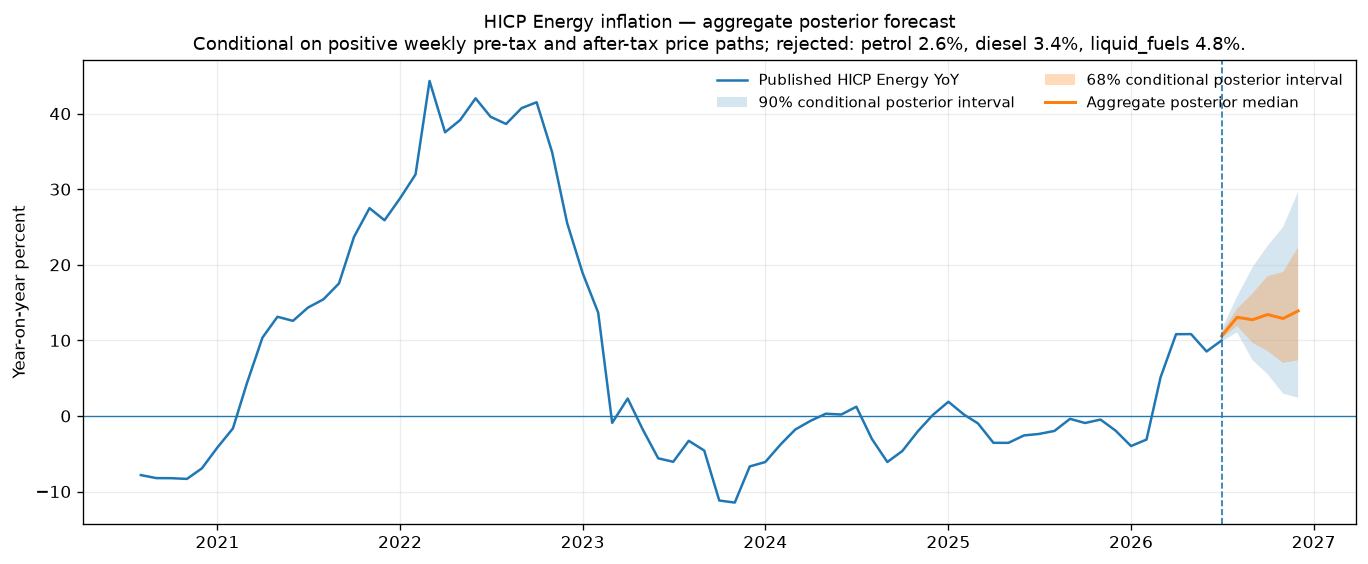

In [12]:

energy_level_fan = summarise_draw_paths(
    energy_baseline["level_paths"],
    aggregate_dates,
)
energy_yoy_fan = summarise_draw_paths(
    energy_baseline_yoy["yoy_paths"],
    aggregate_dates,
)

display(energy_level_fan)
display(energy_yoy_fan)

actual_energy = indices["hicp_energy"].dropna()

weekly_rejection_note = ", ".join(
    f"{model} {100.0 * weekly_price_draw_filter[model]['rejection_rate']:.1f}%"
    for model in WEEKLY_MODELS
)
fan_condition_note = (
    "Conditional on positive weekly pre-tax and after-tax price paths; "
    f"rejected: {weekly_rejection_note}."
)

fig, ax = plt.subplots(figsize=(11.5, 4.8))
history = actual_energy.iloc[-72:]
ax.plot(history.index, history.to_numpy(), label="Published HICP Energy")
ax.fill_between(
    aggregate_dates,
    energy_level_fan["q05"].to_numpy(),
    energy_level_fan["q95"].to_numpy(),
    alpha=0.18,
    label="90% conditional posterior interval",
)
ax.fill_between(
    aggregate_dates,
    energy_level_fan["q16"].to_numpy(),
    energy_level_fan["q84"].to_numpy(),
    alpha=0.28,
    label="68% conditional posterior interval",
)
ax.plot(
    aggregate_dates,
    energy_level_fan["q50"].to_numpy(),
    linewidth=1.8,
    label="Aggregate posterior median",
)
ax.axvline(actual_energy.index[-1], linestyle="--", linewidth=1.0)
ax.set_title("HICP Energy index — aggregate posterior forecast\n" + fan_condition_note)
ax.set_ylabel("Index")
ax.grid(alpha=0.22)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()

actual_yoy = 100.0 * (actual_energy / actual_energy.shift(12) - 1.0)

fig, ax = plt.subplots(figsize=(11.5, 4.8))
history_yoy = actual_yoy.dropna().iloc[-72:]
ax.plot(history_yoy.index, history_yoy.to_numpy(), label="Published HICP Energy YoY")
ax.fill_between(
    aggregate_dates,
    energy_yoy_fan["q05"].to_numpy(),
    energy_yoy_fan["q95"].to_numpy(),
    alpha=0.18,
    label="90% conditional posterior interval",
)
ax.fill_between(
    aggregate_dates,
    energy_yoy_fan["q16"].to_numpy(),
    energy_yoy_fan["q84"].to_numpy(),
    alpha=0.28,
    label="68% conditional posterior interval",
)
ax.plot(
    aggregate_dates,
    energy_yoy_fan["q50"].to_numpy(),
    linewidth=1.8,
    label="Aggregate posterior median",
)
ax.axhline(0.0, linewidth=0.8)
ax.axvline(actual_energy.index[-1], linestyle="--", linewidth=1.0)
ax.set_title("HICP Energy inflation — aggregate posterior forecast\n" + fan_condition_note)
ax.set_ylabel("Year-on-year percent")
ax.grid(alpha=0.22)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()



## 10. Exact component contributions

For Laspeyres term \(T_{i,t}\) and aggregate index \(A_t\),

\[
Contribution_{i,t}
=
100\frac{T_{i,t}-T_{i,t-12}}{A_{t-12}}.
\]

Hence, draw by draw,

\[
\sum_i Contribution_{i,t}
=
100\left(\frac{A_t}{A_{t-12}}-1\right).
\]

This definition stays additive through January weight changes.


Maximum draw-wise contribution additivity error: 4.263e-14


,car_fuels,liquid_fuels,gas,electricity,heat_energy,solid_fuels,HICP Energy YoY median,sum of median contributions
date,,,,,,,,
2026-07-01,6.625896,0.558034,1.879326,1.067809,0.119925,0.335790,10.574163,10.586780
2026-08-01,8.507100,0.777858,2.195263,1.202874,0.127676,0.339655,13.056494,13.150426
2026-09-01,7.900477,0.788383,2.320111,1.318744,0.149695,0.337402,12.728863,12.814812
2026-10-01,8.176448,0.827945,2.461977,1.446503,0.153009,0.321449,13.420567,13.387333
2026-11-01,7.504282,0.691100,2.618618,1.430230,0.144360,0.306165,12.892732,12.694756
2026-12-01,8.417921,0.845821,2.777950,1.362967,0.148454,0.302019,13.896496,13.855132


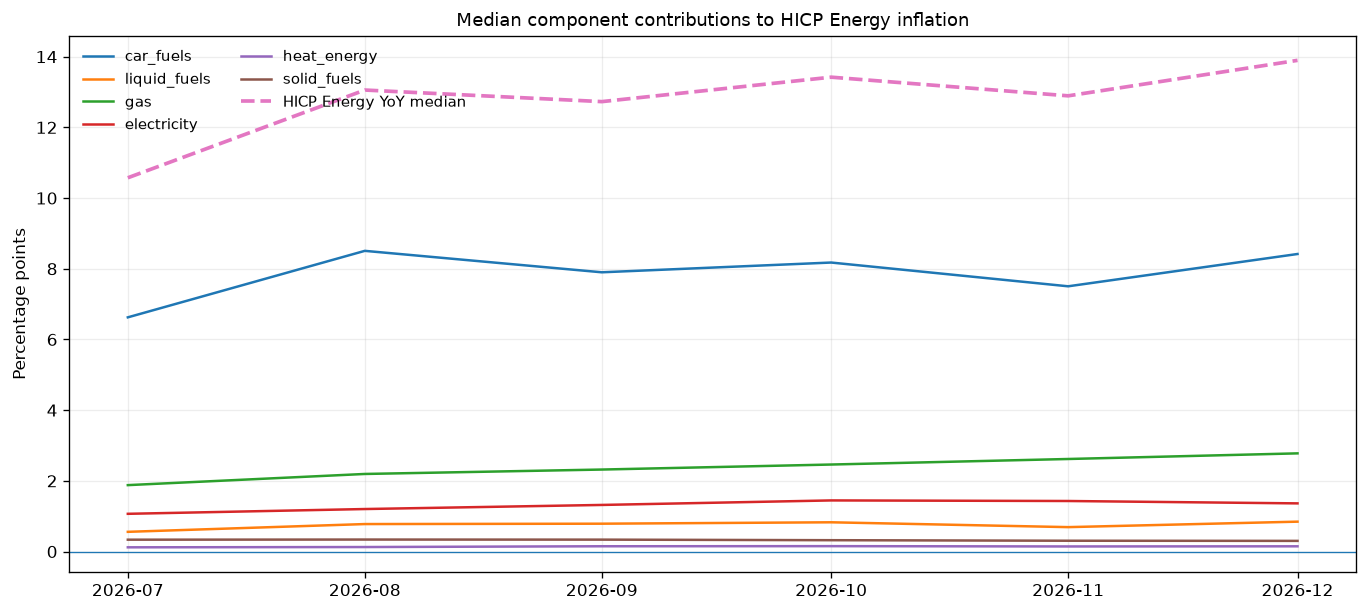

In [13]:

contribution_paths = np.asarray(
    energy_baseline_yoy["contribution_paths"],
    dtype=float,
)
contribution_names = list(energy_baseline_yoy["components"])

median_contributions = pd.DataFrame(
    np.nanmedian(contribution_paths, axis=0),
    index=aggregate_dates,
    columns=contribution_names,
)
median_contributions["HICP Energy YoY median"] = np.nanmedian(
    energy_baseline_yoy["yoy_paths"],
    axis=0,
)
median_contributions["sum of median contributions"] = (
    median_contributions[contribution_names].sum(axis=1, min_count=1)
)

# The equality that matters is draw-wise. This is the hard numerical guard.
draw_additivity_error = np.asarray(
    energy_baseline_yoy["additivity_error"],
    dtype=float,
)
finite_additivity = np.isfinite(draw_additivity_error)
max_additivity_error = (
    float(np.max(np.abs(draw_additivity_error[finite_additivity])))
    if finite_additivity.any()
    else np.nan
)
print(f"Maximum draw-wise contribution additivity error: {max_additivity_error:.3e}")
assert not np.isfinite(max_additivity_error) or max_additivity_error < 1e-10

display(median_contributions)

fig, ax = plt.subplots(figsize=(11.5, 5.2))
for column in contribution_names:
    ax.plot(
        median_contributions.index,
        median_contributions[column],
        label=column,
    )
ax.plot(
    median_contributions.index,
    median_contributions["HICP Energy YoY median"],
    linewidth=2.2,
    linestyle="--",
    label="HICP Energy YoY median",
)
ax.axhline(0.0, linewidth=0.8)
ax.set_title("Median component contributions to HICP Energy inflation")
ax.set_ylabel("Percentage points")
ax.grid(alpha=0.22)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()



## 11. Baseline versus tax scenario

The tax scenario is an **ex-post accounting scenario**. It never changes the pre-tax BVAR draws.

The scenario impact is calculated from matched aggregate draws:

\[
\Delta\pi_t^{tax}
=
\pi_{t,\ scenario}^{Energy}
-
\pi_{t,\ baseline}^{Energy}.
\]


In [14]:

scenario_active = any(value is not None for value in TAX_SCENARIOS.values())

scenario_level_fan = summarise_draw_paths(
    energy_scenario["level_paths"],
    aggregate_dates,
)
scenario_yoy_fan = summarise_draw_paths(
    energy_scenario_yoy["yoy_paths"],
    aggregate_dates,
)

scenario_impact_paths = (
    np.asarray(energy_scenario_yoy["yoy_paths"], dtype=float)
    - np.asarray(energy_baseline_yoy["yoy_paths"], dtype=float)
)
scenario_impact_fan = summarise_draw_paths(
    scenario_impact_paths,
    aggregate_dates,
)

if scenario_active:
    display(
        pd.concat(
            {
                "baseline_yoy": energy_yoy_fan,
                "scenario_yoy": scenario_yoy_fan,
                "scenario_impact_pp": scenario_impact_fan,
            },
            axis=1,
        )
    )

    fig, ax = plt.subplots(figsize=(11.5, 4.8))
    ax.plot(
        aggregate_dates,
        energy_yoy_fan["q50"].to_numpy(),
        label="Baseline median",
    )
    ax.plot(
        aggregate_dates,
        scenario_yoy_fan["q50"].to_numpy(),
        linestyle="--",
        label="Tax-scenario median",
    )
    ax.fill_between(
        aggregate_dates,
        scenario_impact_fan["q16"].to_numpy(),
        scenario_impact_fan["q84"].to_numpy(),
        alpha=0.20,
        label="Scenario impact 68% interval",
    )
    ax.set_title("HICP Energy inflation — baseline versus tax scenario")
    ax.set_ylabel("Percent / percentage-point impact")
    ax.grid(alpha=0.22)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()
else:
    print("No tax scenario is active. Scenario and baseline aggregate paths are identical.")


No tax scenario is active. Scenario and baseline aggregate paths are identical.



## 12. Save the aggregate result for the dashboard

The output contains draw-wise HICP Energy levels, YoY inflation, exact contributions, the baseline/scenario pairing and the complete aggregation metadata.

The dashboard should read this store rather than reimplementing the chain-linking logic.


In [15]:

aggregate_config = {
    "vintage": str(VINTAGE),
    "forecast_name": FORECAST_NAME,
    "n_aggregate_draws_requested": int(N_AGG_DRAWS),
    "n_aggregate_draws_effective": int(N_AGG_DRAWS_EFFECTIVE),
    "transport_draws_effective": int(N_TRANSPORT_DRAWS),
    "pairing_seed": int(PAIRING_SEED),
    "weekly_tax_mode_requested": WEEKLY_TAX_MODE,
    "weekly_tax_mode_effective": WEEKLY_TAX_MODE_EFFECTIVE,
    "tax_scenarios": TAX_SCENARIOS,
    "component_forecast_stores": {
        name: str(path) for name, path in FORECAST_STORES.items()
    },
    "wob_hicp_proxy_diagnostics": {
        name: diagnostic.as_dict()
        for name, diagnostic in proxy_diagnostics.items()
    },
    "weekly_price_admissibility": weekly_price_draw_filter,
    "final_component_pool_sizes": final_component_pool_sizes,
    "transport_pool_sizes": transport_pool_sizes,
    "predictive_distribution_interpretation": (
        "posterior predictive conditional on finite, strictly positive weekly "
        "pre-tax and after-tax consumer-price paths for the weekly fuel models"
    ),
    "weekly_price_to_hicp_method": (
        "proportional WOB price-relative rebasing to latest common HICP month"
    ),
    "weight_policy": energy_baseline["future_weight_policy"],
    "cross_model_dependence": (
        "independent random pairing of marginal component predictive paths; "
        "this is not a joint posterior across the seven separately estimated BVARs"
    ),
    "other_transport_fuels_forecast": (
        "latest published HICP level held constant over the forecast horizon"
    ),
}

config_json = json.dumps(aggregate_config, sort_keys=True, default=str)
aggregate_run_id = hashlib.sha256(config_json.encode("utf-8")).hexdigest()[:20]

AGGREGATE_DIR = (
    RESULTS_ROOT
    / "hicp_energy_aggregate"
    / str(VINTAGE)
    / aggregate_run_id
)

if SAVE_AGGREGATE_RESULT:
    AGGREGATE_DIR.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        AGGREGATE_DIR / "aggregate_draws.npz",
        baseline_level_paths=np.asarray(energy_baseline["level_paths"], dtype=float),
        baseline_yoy_paths=np.asarray(energy_baseline_yoy["yoy_paths"], dtype=float),
        baseline_contribution_paths=np.asarray(
            energy_baseline_yoy["contribution_paths"], dtype=float
        ),
        scenario_level_paths=np.asarray(energy_scenario["level_paths"], dtype=float),
        scenario_yoy_paths=np.asarray(energy_scenario_yoy["yoy_paths"], dtype=float),
        scenario_contribution_paths=np.asarray(
            energy_scenario_yoy["contribution_paths"], dtype=float
        ),
        scenario_impact_yoy_paths=np.asarray(scenario_impact_paths, dtype=float),
        petrol_retained_original_draw_indices=np.asarray(
            weekly_hicp_paths["petrol"]["retained_original_draw_indices"], dtype=int
        ),
        diesel_retained_original_draw_indices=np.asarray(
            weekly_hicp_paths["diesel"]["retained_original_draw_indices"], dtype=int
        ),
        liquid_fuels_retained_original_draw_indices=np.asarray(
            weekly_hicp_paths["liquid_fuels"]["retained_original_draw_indices"], dtype=int
        ),
        transport_petrol_pair_indices=np.asarray(
            transport_pair_indices["hicp_petrol"], dtype=int
        ),
        transport_diesel_pair_indices=np.asarray(
            transport_pair_indices["hicp_diesel"], dtype=int
        ),
        final_car_fuels_pair_indices=np.asarray(
            final_pair_indices["car_fuels"], dtype=int
        ),
        final_liquid_fuels_pair_indices=np.asarray(
            final_pair_indices["liquid_fuels"], dtype=int
        ),
        final_gas_pair_indices=np.asarray(final_pair_indices["gas"], dtype=int),
        final_electricity_pair_indices=np.asarray(
            final_pair_indices["electricity"], dtype=int
        ),
        final_heat_energy_pair_indices=np.asarray(
            final_pair_indices["heat_energy"], dtype=int
        ),
        final_solid_fuels_pair_indices=np.asarray(
            final_pair_indices["solid_fuels"], dtype=int
        ),
    )

    metadata = {
        **aggregate_config,
        "aggregate_run_id": aggregate_run_id,
        "path_dates": [date.isoformat() for date in aggregate_dates],
        "components": list(energy_baseline["components"]),
        "weight_year_used": {
            date.isoformat(): int(year)
            for date, year in energy_baseline["weight_year_used"].items()
        },
        "historical_validation_max_errors": {
            name: float(value)
            for name, value in historical_validation["summary"]["max_abs_error"].items()
        },
        "six_model_history_max_error": float(
            model_history["summary"]["max_abs_error"].iloc[0]
        ),
        "six_model_history_annual_reanchored_max_error": float(
            model_history["summary"]["annual_reanchored_max_abs_error"].iloc[0]
        ),
        "maximum_drawwise_contribution_additivity_error": max_additivity_error,
        "scenario_active": bool(scenario_active),
    }
    (AGGREGATE_DIR / "metadata.json").write_text(
        json.dumps(metadata, indent=2, default=str),
        encoding="utf-8",
    )

    energy_level_fan.to_csv(AGGREGATE_DIR / "baseline_level_fan.csv")
    energy_yoy_fan.to_csv(AGGREGATE_DIR / "baseline_yoy_fan.csv")
    scenario_level_fan.to_csv(AGGREGATE_DIR / "scenario_level_fan.csv")
    scenario_yoy_fan.to_csv(AGGREGATE_DIR / "scenario_yoy_fan.csv")
    scenario_impact_fan.to_csv(AGGREGATE_DIR / "scenario_impact_yoy_fan.csv")
    median_contributions.to_csv(
        AGGREGATE_DIR / "median_component_contributions.csv"
    )
    proxy_table.to_csv(AGGREGATE_DIR / "weekly_wob_hicp_proxy_diagnostics.csv")
    pd.DataFrame(weekly_price_draw_filter).T.to_csv(
        AGGREGATE_DIR / "weekly_price_admissibility_diagnostics.csv"
    )
    historical_validation["summary"].to_csv(
        AGGREGATE_DIR / "historical_reconstruction_summary.csv"
    )

    print(f"Saved aggregate run: {AGGREGATE_DIR}")
else:
    print("SAVE_AGGREGATE_RESULT=False: aggregate result was not written.")


Saved aggregate run: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\results\hicp_energy_aggregate\20260808\429fcdfa2c01b40fc899



## 13. Final audit

The aggregate run is acceptable only if:

- every historical reconstruction guard passed;
- the six-model historical HICP Energy reconstruction passed;
- draw-wise contributions add exactly to aggregate YoY inflation;
- all component forecasts refer to the same processed vintage;
- the effective weekly tax mode is visible in the metadata;
- any future weight carry-forward is explicitly recorded.

At this point the dashboard can consume the aggregate result store without duplicating the econometric or chain-linking code.


In [16]:

audit = pd.Series({
    "processed vintage": VINTAGE,
    "forecast contract": FORECAST_NAME,
    "all annual re-anchored historical hard gates": bool(
        historical_validation["summary"]["annual_reanchored_pass"].all()
    ),
    "all cumulative reconstruction watch limits": bool(
        historical_validation["summary"]["cumulative_watch_pass"].all()
    ),
    "six-model annual re-anchored hard gate": bool(
        model_history["summary"]["annual_reanchored_pass"].iloc[0]
    ),
    "six-model cumulative watch": bool(
        model_history["summary"]["cumulative_watch_pass"].iloc[0]
    ),
    "six-model cumulative max error": float(
        model_history["summary"]["max_abs_error"].iloc[0]
    ),
    "six-model annual re-anchored max error": float(
        model_history["summary"]["annual_reanchored_max_abs_error"].iloc[0]
    ),
    "maximum draw-wise contribution additivity error": max_additivity_error,
    "weekly tax mode effective": WEEKLY_TAX_MODE_EFFECTIVE,
    "tax scenario active": scenario_active,
    "aggregate path start": aggregate_dates.min(),
    "aggregate path end": aggregate_dates.max(),
    "aggregate posterior draws": int(energy_baseline["level_paths"].shape[0]),
    "aggregate output directory": (
        str(AGGREGATE_DIR) if SAVE_AGGREGATE_RESULT else "not saved"
    ),
})
display(audit.to_frame("value"))

assert_reconstruction_suite(historical_validation)
assert_reconstruction_suite(model_history)
assert not np.isfinite(max_additivity_error) or max_additivity_error < 1e-10

print("Notebook 10 aggregation audit: PASS")


,value
processed vintage,20260808
forecast contract,unconditional
all annual re-anchored historical hard gates,True
all cumulative reconstruction watch limits,True
six-model annual re-anchored hard gate,True
six-model cumulative watch,True
six-model cumulative max error,0.006756
six-model annual re-anchored max error,0.008318
maximum draw-wise contribution additivity error,0.0
weekly tax mode effective,official_wob_tax_reattribution


Notebook 10 aggregation audit: PASS
